In [22]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter, MultipleLocator



EXPERIMENT_ROOT = Path("/shared/data_zfs/blue2959/ND_Aligner/experiments/v2.1/coupling_lambda_search")
OUTPUT_PATH = EXPERIMENT_ROOT / "coupling_lambda_decay_wbe.png"
DIR_PATTERN = "v2.1_vctk+coupling_lambda_decay=*"
LAMBDA_PATTERN = re.compile(r"coupling_lambda_decay=([0-9.]+)$")


def extract_lambda(path: Path) -> float:
    match = LAMBDA_PATTERN.search(path.name)
    if match is None:
        raise ValueError(f"Cannot extract lambda from: {path.name}")

    return float(match.group(1))


experiment_dirs = sorted(
    EXPERIMENT_ROOT.glob(DIR_PATTERN),
    key=extract_lambda,
)

if not experiment_dirs:
    raise FileNotFoundError(
        f"No experiment directories found with pattern: {DIR_PATTERN}"
    )

In [23]:
# Font sizes
tick_fontsize = 15
axis_label_fontsize = 18
legend_fontsize = 14

In [37]:
# ============================================================
# Configuration
# ============================================================
conv1d_rf13_dir = (
    EXPERIMENT_ROOT / "v2.1_vctk+conv_1d_dec_RF=13"
)

exclude_lambda = [
    3.0,
    1.75,
    0.25,
    1.25,
    0.75,
]

plot_step_interval = 2500

x_min = 2000
x_max = 176000

wbe_y_min = 20.5
wbe_y_max = 32.5

p25_y_min = 47.5
p25_y_max = 73.5

tick_fontsize = 20
axis_label_fontsize = 23
legend_fontsize = 16

coupling_linewidth = 1.7
baseline_linewidth = 2.5


plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


# ============================================================
# Experiment discovery
# ============================================================

LAMBDA_PATTERN = re.compile(
    r"coupling_lambda_decay=([-+]?(?:\d+(?:\.\d*)?|\.\d+))$"
)


def extract_lambda(experiment_dir: Path) -> float:
    match = LAMBDA_PATTERN.search(experiment_dir.name)

    if match is None:
        raise ValueError(
            f"Cannot extract coupling weight from: "
            f"{experiment_dir.name}"
        )

    return float(match.group(1))


experiment_dirs = sorted(
    EXPERIMENT_ROOT.glob(
        "v2.1_vctk+coupling_lambda_decay=*"
    ),
    key=extract_lambda,
)


# ============================================================
# Metric loading
# ============================================================

def load_eval_metrics(
    csv_path: Path,
    step_interval: int,
) -> pd.DataFrame | None:
    if not csv_path.exists():
        print(f"[SKIP] CSV not found: {csv_path}")
        return None

    if step_interval <= 0:
        raise ValueError(
            "step_interval must be a positive integer."
        )

    df = pd.read_csv(csv_path)

    required_columns = {
        "step",
        "word_boundary_error",
        "p_word_25ms",
    }

    missing_columns = required_columns - set(df.columns)

    if missing_columns:
        print(
            f"[SKIP] Missing columns in {csv_path}: "
            + f"{sorted(missing_columns)}"
        )
        return None

    df = (
        df[
            [
                "step",
                "word_boundary_error",
                "p_word_25ms",
            ]
        ]
        .dropna()
        .sort_values("step")
        .drop_duplicates(
            subset="step",
            keep="last",
        )
        .copy()
    )

    df = df[
        df["step"] % step_interval == 0
    ].copy()

    if df.empty:
        print(
            f"[SKIP] No steps divisible by "
            + f"{step_interval}: {csv_path}"
        )
        return None

    # WBE: seconds -> milliseconds
    df["word_boundary_error"] *= 1000.0

    return df


# ============================================================
# Select coupling experiments
# ============================================================

selected_experiments: list[tuple[float, Path]] = []

for experiment_dir in experiment_dirs:
    csv_path = experiment_dir / "eval_metrics.csv"

    if not csv_path.exists():
        print(f"[SKIP] CSV not found: {csv_path}")
        continue

    lambda_value = extract_lambda(experiment_dir)

    is_excluded = any(
        abs(lambda_value - excluded_value) < 1e-3
        for excluded_value in exclude_lambda
    )

    if is_excluded:
        continue

    selected_experiments.append(
        (lambda_value, experiment_dir)
    )

selected_experiments.sort(
    key=lambda item: item[0]
)

if not selected_experiments:
    raise RuntimeError(
        "No valid coupling experiments were found."
    )


coupling_experiments = [
    item
    for item in selected_experiments
    if abs(item[0]) >= 1e-3
]


# ============================================================
# Color palette
# ============================================================

cmap = plt.get_cmap("viridis")

coupling_colors = cmap(
    np.linspace(
        0.10,
        0.90,
        max(len(coupling_experiments), 1),
    )
)

coupling_color_map = {
    lambda_value: color
    for color, (lambda_value, _) in zip(
        coupling_colors,
        coupling_experiments,
    )
}

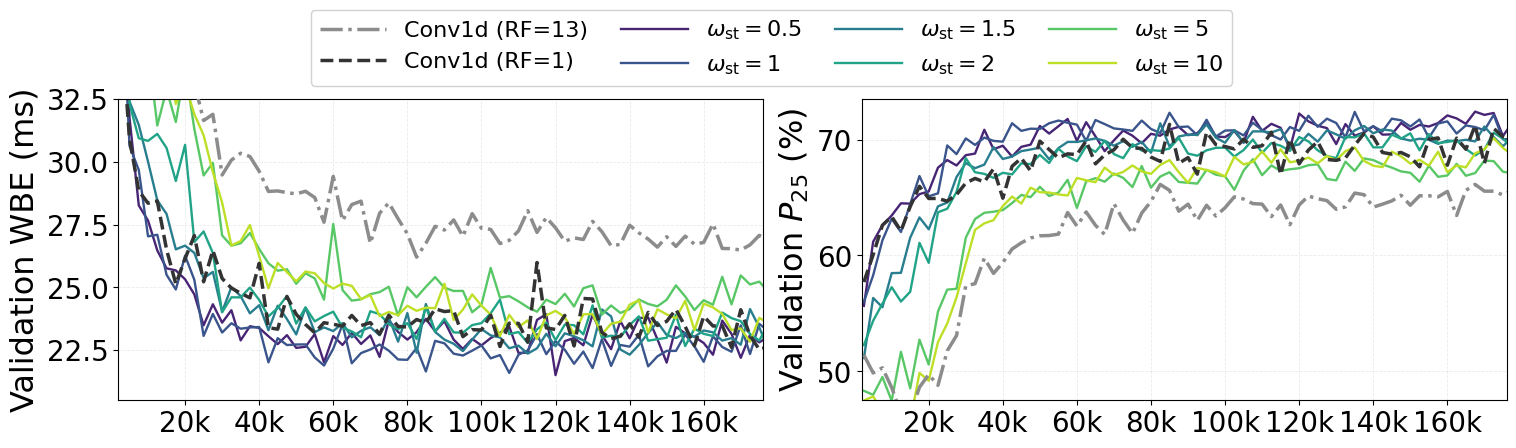

In [38]:

# ============================================================
# Plot helpers
# ============================================================

fig, (ax_wbe, ax_p25) = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(15, 4.5),
    sharex=True,
)

plotted_count = 0


def plot_both_metrics(
    df: pd.DataFrame,
    *,
    color,
    linewidth: float,
    linestyle: str,
    label: str,
    zorder: int,
) -> None:
    ax_wbe.plot(
        df["step"],
        df["word_boundary_error"],
        color=color,
        linewidth=linewidth,
        linestyle=linestyle,
        label=label,
        zorder=zorder,
    )

    ax_p25.plot(
        df["step"],
        df["p_word_25ms"],
        color=color,
        linewidth=linewidth,
        linestyle=linestyle,
        label=label,
        zorder=zorder,
    )


# ============================================================
# Conv1d (RF=13)
# ============================================================

conv1d_rf13_df = load_eval_metrics(
    conv1d_rf13_dir / "eval_metrics.csv",
    step_interval=plot_step_interval,
)

if (
    conv1d_rf13_df is not None
    and not conv1d_rf13_df.empty
):
    plot_both_metrics(
        conv1d_rf13_df,
        color="0.55",
        linewidth=baseline_linewidth,
        linestyle="-.",
        label="Conv1d (RF=13)",
        zorder=5,
    )

    plotted_count += 1


# ============================================================
# Conv1d (RF=1) and coupling-decoder experiments
# ============================================================

for lambda_value, experiment_dir in selected_experiments:
    df = load_eval_metrics(
        experiment_dir / "eval_metrics.csv",
        step_interval=plot_step_interval,
    )

    if df is None or df.empty:
        continue

    if abs(lambda_value) < 1e-3:
        # omega_st=0 corresponds to the point-wise decoder.
        plot_both_metrics(
            df,
            color="0.20",
            linewidth=baseline_linewidth,
            linestyle="--",
            label="Conv1d (RF=1)",
            zorder=5,
        )
    else:
        plot_both_metrics(
            df,
            color=coupling_color_map[lambda_value],
            linewidth=coupling_linewidth,
            linestyle="-",
            label=(
                rf"$\omega_{{\mathrm{{st}}}}"
                rf"={lambda_value:g}$"
            ),
            zorder=2,
        )

    plotted_count += 1


if plotted_count == 0:
    raise RuntimeError(
        "No valid evaluation data were found."
    )


# ============================================================
# Axis formatting
# ============================================================

def format_step_k(x: float, _position: int) -> str:
    if abs(x) < 1e-9:
        return "0"

    return f"{x / 1000:g}k"


for ax in (ax_wbe, ax_p25):
    ax.set_xlim(x_min, x_max)

    # ax.set_xlabel(
    #     "Training Step",
    #     fontsize=axis_label_fontsize,
    # )

    # 20k, 40k, 60k, ...
    ax.xaxis.set_major_locator(
        MultipleLocator(20000)
    )

    ax.xaxis.set_major_formatter(
        FuncFormatter(format_step_k)
    )

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=tick_fontsize,
    )

    ax.grid(
        visible=True,
        which="major",
        linestyle="--",
        linewidth=0.6,
        alpha=0.25,
    )


# Left subplot: WBE
ax_wbe.set_ylim(
    wbe_y_min,
    wbe_y_max,
)

ax_wbe.set_ylabel(
    "Validation WBE (ms)",
    fontsize=axis_label_fontsize,
)


# Right subplot: P25
if p25_y_min is not None or p25_y_max is not None:
    current_y_min, current_y_max = ax_p25.get_ylim()

    ax_p25.set_ylim(
        p25_y_min
        if p25_y_min is not None
        else current_y_min,
        p25_y_max
        if p25_y_max is not None
        else current_y_max,
    )

ax_p25.set_ylabel(
    r"Validation $P_{25}$ (%)",
    fontsize=axis_label_fontsize,
)


# ============================================================
# Single figure-level legend
# ============================================================

handles, labels = ax_wbe.get_legend_handles_labels()

# 혹시 같은 label이 여러 번 생긴 경우 제거
unique_legend_items = {}

for handle, label in zip(handles, labels):
    if label not in unique_legend_items:
        unique_legend_items[label] = handle

fig.legend(
    unique_legend_items.values(),
    unique_legend_items.keys(),
    loc="upper center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=4,
    framealpha=0.9,
    handlelength=3.0,
    columnspacing=1.5,
    fontsize=legend_fontsize,
)


# 범례가 들어갈 상단 공간 확보
fig.tight_layout(
    rect=(0.0, 0.0, 1.0, 0.82)
)


In [39]:
OUTPUT_PDF = EXPERIMENT_ROOT / "coupling_decoder_training_curves.pdf"
OUTPUT_PNG = EXPERIMENT_ROOT / "coupling_decoder_training_curves.png"

fig.savefig(
    OUTPUT_PDF,
    format="pdf",
    bbox_inches="tight",
)

fig.savefig(
    OUTPUT_PNG,
    format="png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"Saved PDF: {OUTPUT_PDF.resolve()}")
print(f"Saved PNG: {OUTPUT_PNG.resolve()}")

Saved PDF: /shared/data_zfs/blue2959/ND_Aligner/experiments/v2.1/coupling_lambda_search/coupling_decoder_training_curves.pdf
Saved PNG: /shared/data_zfs/blue2959/ND_Aligner/experiments/v2.1/coupling_lambda_search/coupling_decoder_training_curves.png
